## Урок 6. Hugging Face и BERT

### План

1. Знакомство с Hugging Face
    1. Дочерние библиотеки
    1. Токенизаторы
    1. Датасеты
    1. Трансформеры
1. Задача классификации
    1. Zero-shot
    1. BERT для извлечения признаков

## Hugging Face 🤗

Hugging Face – это компания, которая разрабатывает инструменты и библиотеки для работы с моделями глубинного обучения, особенно в области NLP. Помимо разработок компании, у Hugging Face есть [hub](https://huggingface.co/docs/hub/index), в который любой пользователь может загрузить свою модель или датасет. Вот список основных библиотек, которые нам пригодятся:

1. [`transformers`](https://huggingface.co/docs/transformers/index) – содержит реализации с весами для всех наиболее популярных трансформерных моделей, а также токенизаторы к ним.
1. [`datasets`](https://huggingface.co/docs/datasets/index) – библиотека для загрузки и обработки всех датасетов из huggingface hub.
1. [`tokenizers`](https://huggingface.co/docs/tokenizers/index) – библиотека для обучения своих токенизаторов, которой почти _никто не пользуется_ напрямую. Лучше брать токенизаторы из `transformers`.
1. [`evaluate`](https://huggingface.co/docs/evaluate/index) – хранит реализации огромного числа метрик (возможно, вообще всех) для оценки качества моделей.
1. [`accelerate`](https://huggingface.co/docs/accelerate/index) – библиотека с трюками для ускорения обучения и примерения моделей.
1. [`bitsandbytes`](https://huggingface.co/docs/bitsandbytes/index) – предназначена для обучения и применения квантизованных моделей.

Главное преимущество Hugging Face – удобство использования. Все библиотеки могут работать друг с другом и все классы внутри одной библиотеки имеют одинаковый интерфейс.

## Токенизаторы

Существуют два вида токенизаторов:
1. `Tokenizer` – реализован на Python из-за того, что это проще.
1. `TokenizerFast` – реализован на Rust с использованием библиотеки `tokenizers`.

По умолчанию всегда используется `TokenizerFast`, если он доступен.

In [2]:
from transformers import AutoTokenizer, AutoModelForMaskedLM


In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

Любой токенизатор можно импортировать явно.

In [2]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

Можно не брать предобученный токенизатор и задать словарь для токенизации вручную.

In [3]:
with open('vocab_file.txt', 'w') as f:
    f.write('\n'.join(tokenizer.vocab.keys()))

In [4]:
tokenizer = BertTokenizer('vocab_file.txt', model_max_length=512)
tokenizer

BertTokenizer(name_or_path='', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [5]:
tokenizer.encode('Some random text')

[101, 2070, 6721, 3793, 102]

У многих токенизаторов есть `cased` и `uncased` версия. Разница между ними в том, что `cased` не приводит текст к нижнему регистру.

In [6]:
from transformers import BertTokenizer

cased_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
uncased_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

cased_result = cased_tokenizer.decode(cased_tokenizer.encode('Some Random text'))
uncased_result = uncased_tokenizer.decode(uncased_tokenizer.encode('Some Random text'))

print('Cased:', cased_result)
print('Uncased:', uncased_result)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Cased: [CLS] Some Random text [SEP]
Uncased: [CLS] some random text [SEP]


## `datasets`


Любые датасеты, которые лежат на платформе [Hugging Face](https://huggingface.co/datasets), можно скачать одной строчкой, используя [`load_dataset`](https://huggingface.co/docs/datasets/v2.19.0/en/package_reference/loading_methods#datasets.load_dataset). После этого их можно удобно модифицировать с помощью `map`.

In [3]:
! pip3 install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 21.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [4]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")
dataset

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Посмотрим на то, как работает `map`, и заодно сравним скорость токенизаторов.

In [9]:
from transformers import BertTokenizer, BertTokenizerFast

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer_fast = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [10]:
from functools import partial

def tokenize(tokenizer, sample):
    return tokenizer(sample['text'])

dataset = dataset.map(
    partial(tokenize, tokenizer_fast),
    batched=True,
    num_proc=30,
    desc="Tokenization",
    batch_size=1000,
)

Tokenization (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenization (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

In [11]:
dataset = dataset.map(
    partial(tokenize, tokenizer),
    batched=True,
    num_proc=30,
    desc="Tokenization",
    batch_size=1000,
)

Tokenization (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenization (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

Быстрый токенизатор оказался примерно в 3 раза быстрее простого.

Функция в `map` всегда должна возвращать словарь. Название ключа станет названием новой колонки.

In [12]:
def get_len(sample):
    return {'len': [len(x) for x in sample['input_ids']]}

dataset_with_lens = dataset.map(
    get_len,
    batched=True,
    num_proc=30,
    desc="Get length",
    batch_size=1000,
)

Get length (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Get length (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

In [19]:
dataset_with_lens['train']['len'][:5]

[41, 53, 51, 49, 53]

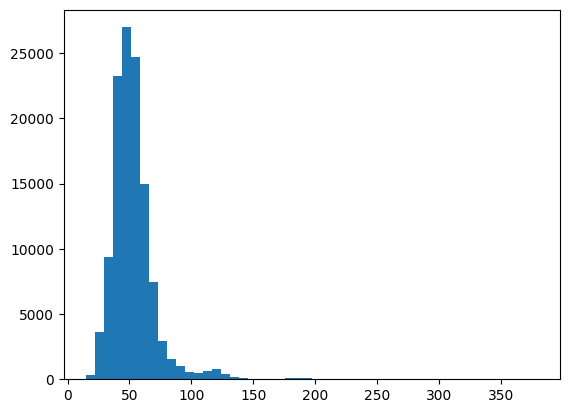

In [20]:
import matplotlib.pyplot as plt

plt.hist(dataset_with_lens['train']['len'], bins=50);

Иногда еще полезно бывает поменять тип данных в столбцах датасета.

In [21]:
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
dataset['test'][0]

{'label': tensor(2),
 'input_ids': tensor([  101, 10069,  2005,  1056,  1050, 11550,  2044,  7566,  9209,  5052,
          3667,  2012,  6769,  2047,  8095,  2360,  2027,  2024,  1005,  9364,
          1005,  2044,  7566,  2007, 16654,  6687,  3813,  2976,  9587, 24848,
          1012,   102]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1])}

## Трансформерные модели в Hugging Face

Любую модель вместе с ее весами можно загрузить точно так же, как токенизатор.

In [22]:
from transformers import AutoModel

In [23]:
bert_model = AutoModel.from_pretrained('bert-base-uncased')
bert_model

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

Модели по типу BERT часто дообучаются на небольшие задачи: классификация текста, классификация токенов и т.д. От задачи к задаче формат выхода меняется и, соответственно, требуется специальная голова. В `transformers` это все предусмотрено, для каждой задачи есть своя модификация трансформерной модели.

__Важно:__ При загрузке модели веса для головы не загружаются (откуда им взяться?). Поэтому такую модель использовать без дообучения не получится.

In [24]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoModelForMaskedLM

In [25]:
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased')
bert_model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [26]:
bert_model??

In [27]:
bert_model = AutoModelForTokenClassification.from_pretrained('bert-base-uncased', num_labels=10)
bert_model

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

## Решение задачи классификации (да, опять)

In [7]:
 ! pip3 install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.9 MB/s eta 0:00:00


In [8]:
import numpy as np
import torch
from tqdm.auto import tqdm
import evaluate

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
device

device(type='cuda')

Загрузим метрику точности, она понадобится позже.

In [9]:
accuracy_metric = evaluate.load('accuracy')

### Zero-shot

Во время обучения BERT тренируется демаскировать спрятанные от него токены так, чтобы они подходили по смыслу. Значит, если мы сконструируем пример так, чтобы за маской прятался класс в задаче классификации, BERT будет его предсказывать. Такая парадигма применения модели называется __zero-shot__, потому что модель не обучалась ни на одном примере такой классификации.

Загрузим веса BERT для задачи MLM. Они имеются в наличии, так как BERT предобучался именно на эту задачу.

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Пускай нам нужно классифицировать короткие истории. Такой промпт вполне подойдет.

In [9]:
story_desc = "Elephants are playing in the zoo with monkeys."
prompt = "The story is about [MASK]."

In [10]:
tokenized = tokenizer(f'{story_desc} {prompt}', return_tensors='pt')
tokenized

{'input_ids': tensor([[  101, 16825,  2024,  2652,  1999,  1996,  9201,  2007, 17059,  1012,
          1996,  2466,  2003,  2055,   103,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
output = bert_model(**tokenized)
print(output.logits.shape)
probs = torch.softmax(output.logits[0, -3], dim=0)
probs, tokens = probs.topk(10)  # Берем 10 наиболее вероятных предсказаний

torch.Size([1, 17, 30522])


In [ ]:
for prob, word in zip(probs, tokenizer.convert_ids_to_tokens(tokens)):
    print(f'{word} \tProb: {round(prob.item(), 3)}')

elephants 	Prob: 0.216
monkeys 	Prob: 0.109
animals 	Prob: 0.086
elephant 	Prob: 0.039
children 	Prob: 0.022
monkey 	Prob: 0.02
birds 	Prob: 0.013
lions 	Prob: 0.013
love 	Prob: 0.01
butterflies 	Prob: 0.009


В целом BERT неплохо справляется с задачей и действительно улавливает контекст.

Для того, чтобы применить модель, нам всегда надо сперва токенизировать текст. Для того, чтобы не делать это каждый раз отдельно, можно использовать `pipeline`, в котором токенизация и применение модели объединены.

In [18]:
from datasets import load_dataset

In [11]:
from transformers import pipeline

pipe = pipeline("fill-mask", model="bert-base-uncased", device=device)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda


In [12]:
pipe.tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [13]:
pipe.model

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [14]:
output = pipe(f'{story_desc} {prompt}', top_k=10)
for out in output:
    print(f'{out["token_str"]} \tProb: {round(out["score"], 3)}')

elephants 	Prob: 0.216
monkeys 	Prob: 0.109
animals 	Prob: 0.086
elephant 	Prob: 0.039
children 	Prob: 0.022
monkey 	Prob: 0.02
birds 	Prob: 0.013
lions 	Prob: 0.013
love 	Prob: 0.01
butterflies 	Prob: 0.009


### Классификация новостей

В любой задаче классификации обычно есть набор фиксированных классов. Например, в классификации новостей это _["World", "Sports", "Business", "Sci/Tech"]_.

Мы можем передать этот список в `targets`, чтобы `pipeline` возвращал вероятность только для этих классов.

In [15]:
label2name = ["world", "sports", "business", "technology"]
name2label = {v: i for i, v in enumerate(label2name)}

In [16]:
name2label

{'world': 0, 'sports': 1, 'business': 2, 'technology': 3}

In [21]:
prompt = 'This news is about [MASK].'

prompted_dataset = dataset['test'].map(
    lambda sample: {'text': [f'{text} {prompt}' for text in sample['text']]},
    batched=True,
)
prompted_dataset.set_format(type='torch', columns=['text', 'label'])

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [27]:
prompted_dataset['text'][:5]

["Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul. This news is about [MASK].",
 'The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\\privately funded suborbital space flight, has officially announced the first\\launch date for its manned rocket. This news is about [MASK].',
 'Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins. This news is about [MASK].',
 "Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless 

In [28]:
def zero_shot_predictions(dataset):
    bs = 32
    predictions = []
    for i in tqdm(range(0, len(dataset), bs)):
        output = pipe(dataset[i:i+bs]['text'], targets=label2name, top_k=1)
        predictions.extend([name2label[out[0]['token_str']] for out in output])

    predictions = np.array(predictions)
    return predictions

In [29]:
predictions = zero_shot_predictions(prompted_dataset)

  0%|          | 0/238 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [5]:
accuracy = accuracy_metric.compute(predictions=predictions, references=prompted_dataset['label'])
accuracy['accuracy']

NameError: name 'accuracy_metric' is not defined

По какой-то причине точность довольно низкая. Посмотрим на точности по классам.

In [31]:
per_class_acc = {}
for label in np.unique(prompted_dataset['label']):
    mask = prompted_dataset['label'] == label
    per_class_acc[label2name[label]] = accuracy_metric.compute(
        predictions=predictions[mask],
        references=prompted_dataset['label'][mask]
    )['accuracy']

In [32]:
per_class_acc

{'world': 0.031578947368421054,
 'sports': 0.5131578947368421,
 'business': 0.9636842105263158,
 'technology': 0.3163157894736842}

Видим, что для некоторых классов точность очень высокая, а для некоторых – очень низкая. Очевидно, названия классов недостаточно хорошо их описывают. Давайте попробуем найти более подходящее название для класса `world`.

In [33]:
world_prompted_dataset = prompted_dataset.filter(
    lambda sample: sample['label'] == name2label['world'],
)
world_prompted_dataset

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 1900
})

In [35]:
world_prompted_dataset['label'][:5]

tensor([0, 0, 0, 0, 0])

In [36]:
from collections import Counter

In [37]:
bs = 32
top100_words = Counter()
for i in tqdm(range(0, len(world_prompted_dataset), bs)):
    with torch.inference_mode():
        output = pipe(world_prompted_dataset[i:i+bs]['text'], top_k=100)

    for out in output:
        top100_words += Counter([out[j]['token_str'] for j in range(len(out))])

  0%|          | 0/60 [00:00<?, ?it/s]

In [38]:
top100_words.most_common(20)

[('us', 1896),
 ('it', 1861),
 ('america', 1837),
 ('me', 1821),
 ('you', 1818),
 ('politics', 1726),
 ('news', 1721),
 ('time', 1687),
 ('him', 1651),
 ('china', 1642),
 ('them', 1596),
 ('history', 1474),
 ('canada', 1427),
 ('democracy', 1425),
 ('war', 1408),
 ('life', 1373),
 ('russia', 1348),
 ('freedom', 1343),
 ('terrorism', 1333),
 ('iran', 1328)]

Из 20 самых часто предсказываемых слов больше всего подходит `politics`, поменяем название класса на него.

In [39]:
label2name = ["politics", "sports", "business", "technology"]
name2label = {v: i for i, v in enumerate(label2name)}

In [40]:
name2label

{'politics': 0, 'sports': 1, 'business': 2, 'technology': 3}

In [41]:
prompt = 'This news is about [MASK].'

prompted_dataset = dataset['test'].map(
    lambda sample: {'text': [f'{text} {prompt}' for text in sample['text']]},
    batched=True,
)
prompted_dataset.set_format(type='torch', columns=['text', 'label'])

In [42]:
predictions = zero_shot_predictions(prompted_dataset)

  0%|          | 0/238 [00:00<?, ?it/s]

In [43]:
accuracy = accuracy_metric.compute(predictions=predictions, references=prompted_dataset['label'])
accuracy['accuracy']

0.6128947368421053

Ура, сразу стало гораздо лучше.

Этот пример демонстрирует zero-shot свойства BERT. Понятно, что применять его в таком виде довольно глупо, качество никогда не будет высоким. Гораздо лучше всегда дообучать BERT на задачу классификации или хотя бы использовать его выходы как признаки для линейной модели.

## Линейная модель на выходах BERT

BERT обучался на задачу классификации следующего предложения, поэтому в токене [CLS] хранится информация обо всем тексте. Будем использовать ее как признаки для линейной модели.

In [10]:
from transformers import pipeline

pipe = pipeline("feature-extraction", model="bert-base-uncased", device=device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cuda


In [11]:
def encode_texts(dataset):
    bs = 64
    encodings = []
    for i in tqdm(range(0, len(dataset), bs)):
        output = pipe(dataset[i:i+bs]['text'], return_tensors=True)
        encodings.extend([out[0, 0].cpu() for out in output])

    return encodings

In [13]:
train_dataset = encode_texts(dataset['train'])

  0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
test_dataset = encode_texts(dataset['test'])

100%|██████████| 119/119 [00:58<00:00,  2.04it/s]


У логистической регрессии параметр `multi_class='multinomial'` делает ее мультиклассовой.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class='multinomial').fit(train_dataset, dataset['train']['label'])

predictions = model.predict(test_dataset)

/home/amshabalin/anaconda3/envs/karpov/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy = accuracy_metric.compute(predictions=predictions, references=dataset['test']['label'])
accuracy['accuracy']

0.9005263157894737

Получили довольно высокую точность. Это означает, что BERT извлекает информацию о типе новости, несмотря на то, что мы не учили его это делать в явном виде.

### Резюме

1. Познакомились с основными библиотеками `huggingface` и научились ими пользоваться.
1. Узнали, что BERT способен решать задачу классификации в zero-shot режиме.
1. Использовали BERT для извлечения признаков из текста. Убедились в том, что признаки получаются очень осознанными.